In [6]:
# 열 이름 확인용 (오류나면 이거 먼저 실행)
df = pd.read_excel('skin_irritation.xlsx')
print("실제 열 이름들:")
print(df.columns.tolist())

실제 열 이름들:
['ICE version:', '4.1']


In [7]:
import pandas as pd

# 모든 시트 확인
print("=== 모든 시트 이름 확인 ===")
excel_file = pd.ExcelFile('skin_irritation.xlsx')
print("시트 목록:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")
    # 각 시트의 열 이름 미리보기
    df_temp = pd.read_excel('skin_irritation.xlsx', sheet_name=sheet)
    print(f"  열 개수: {len(df_temp.columns)}, 열 이름: {list(df_temp.columns[:5])}...")

# 데이터가 있는 시트 찾기 (첫 번째 데이터 시트 사용)
first_data_sheet = excel_file.sheet_names[1] if len(excel_file.sheet_names) > 1 else excel_file.sheet_names[0]
print(f"\n데이터 시트 '{first_data_sheet}' 로딩...")

df = pd.read_excel('skin_irritation.xlsx', sheet_name=first_data_sheet)
print(f"\n실제 열 이름들:")
print(df.columns.tolist()[:20])  # 처음 20개만
print(f"데이터 shape: {df.shape}")

=== 모든 시트 이름 확인 ===
시트 목록:
- Metadata
  열 개수: 2, 열 이름: ['ICE version:', '4.1']...
- Data_invitro
  열 개수: 21, 열 이름: ['Record_ID', 'Data_Type', 'Formulation_Name', 'Formulation_ID', 'Chemical_Name']...
- Data_invivo
  열 개수: 25, 열 이름: ['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name']...

데이터 시트 'Data_invitro' 로딩...

실제 열 이름들:
['Record_ID', 'Data_Type', 'Formulation_Name', 'Formulation_ID', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Concentration', 'Concentration_Units', 'Mixture', 'Assay', 'Endpoint', 'Response', 'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox']
데이터 shape: (6259, 21)


In [8]:
import pandas as pd

# 데이터 로드
df = pd.read_excel('skin_irritation.xlsx')

# 1) 필터링
df_filtered = df[
    (df['Mixture'] == 'chemical') &      # (ㄱ) mixture 컬럼: chemical
    (df['Species'] == 'human') &         # (ㄴ) species 컬럼: human  
    (df['Endpoint'] == 'Qualitative classification')  # (ㄷ) endpoint: qualitative classification
].copy()

# 2) label 생성
df_filtered['label'] = df_filtered['Response'].apply(
    lambda x: 0 if x == 'not classified' else 1
)

# 결과 확인
print(f"필터링된 데이터: {len(df_filtered)} 행")
print("Label 분포:")
print(df_filtered['label'].value_counts())
print("\n처음 5개 데이터:")
print(df_filtered[['Mixture', 'Species', 'Endpoint', 'Response', 'label']].head())

KeyError: 'Mixture'

In [9]:
import pandas as pd

# 1. 모든 시트 확인하고 데이터 시트 찾기
excel_file = pd.ExcelFile('skin_irritation.xlsx')
print("📋 전체 시트 목록:")
for i, sheet in enumerate(excel_file.sheet_names):
    print(f"{i}: '{sheet}'")
    
# 2. 데이터가 있는 시트 찾기 (보통 1번 또는 2번 시트)
# 'Data_invitro', 'skin_irritation_invitro', 데이터가 많은 시트 선택
for sheet in excel_file.sheet_names[1:]:  # 첫번째 시트(메타데이터) 제외
    df_temp = pd.read_excel('skin_irritation.xlsx', sheet_name=sheet)
    print(f"\n🔍 시트 '{sheet}' 열 이름 (처음 10개):")
    print(df_temp.columns.tolist()[:10])
    print(f"   행 수: {len(df_temp)}")
    if len(df_temp.columns) > 20:  # 데이터가 많으면 이 시트!
        data_sheet = sheet
        break
else:
    data_sheet = excel_file.sheet_names[1]

print(f"\n✅ 데이터 시트: '{data_sheet}' 선택!")

# 3. 올바른 시트에서 데이터 로드
df = pd.read_excel('skin_irritation.xlsx', sheet_name=data_sheet)

# 4. 실제 열 이름 확인
print("\n📊 실제 열 이름 (처음 20개):")
print(df.columns.tolist()[:20])

# 5. Mixture, Species, Endpoint, Response 열 찾기
mixture_col = None
species_col = None
endpoint_col = None
response_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'mixture' in col_lower:
        mixture_col = col
    if 'species' in col_lower:
        species_col = col  
    if 'endpoint' in col_lower or 'qualitative' in col_lower:
        endpoint_col = col
    if 'response' in col_lower:
        response_col = col

print(f"\n🎯 찾은 열:")
print(f"Mixture: {mixture_col}")
print(f"Species: {species_col}")
print(f"Endpoint: {endpoint_col}")
print(f"Response: {response_col}")

# 6. label 정의 (실제 열 이름 사용)
if all([mixture_col, species_col, endpoint_col]):
    df_filtered = df[
        (df[mixture_col] == 'chemical') &
        (df[species_col] == 'human') & 
        (df[endpoint_col] == 'Qualitative classification')
    ].copy()
    
    if response_col:
        df_filtered['label'] = df_filtered[response_col].apply(
            lambda x: 0 if x == 'not classified' else 1
        )
    
    print(f"\n✅ 필터링 완료: {len(df_filtered)} 행")
    print("Label 분포:")
    print(df_filtered['label'].value_counts())
else:
    print("\n❌ 필요한 열을 찾을 수 없음. 수동 확인 필요")

📋 전체 시트 목록:
0: 'Metadata'
1: 'Data_invitro'
2: 'Data_invivo'

🔍 시트 'Data_invitro' 열 이름 (처음 10개):
['Record_ID', 'Data_Type', 'Formulation_Name', 'Formulation_ID', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Concentration', 'Concentration_Units']
   행 수: 6259

✅ 데이터 시트: 'Data_invitro' 선택!

📊 실제 열 이름 (처음 20개):
['Record_ID', 'Data_Type', 'Formulation_Name', 'Formulation_ID', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Concentration', 'Concentration_Units', 'Mixture', 'Assay', 'Endpoint', 'Response', 'Response_Unit', 'Reference', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox']

🎯 찾은 열:
Mixture: Mixture
Species: None
Endpoint: Endpoint
Response: Response_Unit

❌ 필요한 열을 찾을 수 없음. 수동 확인 필요


In [10]:
import pandas as pd
import numpy as np

# 1. 데이터 불러오기 
# 원본 엑셀 파일 중 Species 컬럼이 존재하는 Data_invivo 시트를 불러옵니다.
df = pd.read_excel('skin_irritation.xlsx', sheet_name='Data_invivo')

# 2. 데이터 필터링 (대소문자 및 공백 무시를 위해 .str.strip().str.lower() 적용)
cond_mixture = df['Mixture'].str.strip().str.lower() == 'chemical'
cond_species = df['Species'].str.strip().str.lower() == 'human'
cond_endpoint = df['Endpoint'].str.strip().str.lower() == 'qualitative classification'

# 세 가지 조건을 모두 만족하는 데이터만 추출
df_filtered = df[cond_mixture & cond_species & cond_endpoint].copy()

# 3. Label (y) 정의
# Response가 'not classified'인 경우 0, 그 외의 값(예: 'Irritant', 'Not classified/Possible irritant' 등)은 1로 설정
df_filtered['label'] = np.where(
    df_filtered['Response'].str.strip().str.lower() == 'not classified', 
    0, 
    1
)

# 데이터 정리 결과 확인
print(f"필터링 후 남은 데이터 개수: {len(df_filtered)}개")
display(df_filtered[['Chemical_Name', 'Mixture', 'Species', 'Endpoint', 'Response', 'label']].head())

필터링 후 남은 데이터 개수: 90개


,Chemical_Name,Mixture,Species,Endpoint,Response,label
0,Alcohol ethoxylate C12-15/E5 phosphate,Chemical,Human,Qualitative classification,Not classified,0
1,C12-13 beta-branched primary alco hol sulfate,Chemical,Human,Qualitative classification,Irritant,1
2,C12-13 beta-branched primary alco hol sulfate/...,Chemical,Human,Qualitative classification,Not classified/Possible irritant,1
5,"N,N-Dimethyl-N-dodecyl amino- betaine",Chemical,Human,Qualitative classification,Irritant,1
6,"Bis[(1-Methylimidazol)-(2- ethyl- hexanoate)],...",Chemical,Human,Qualitative classification,Not classified,0


In [11]:
import pandas as pd
from rdkit import Chem

# (ㄱ), (ㄴ) SMILES 염 제거 및 표준화 함수 정의
def process_smiles(smiles):
    # 결측치나 문자열이 아닌 경우 제외
    if pd.isna(smiles) or not isinstance(smiles, str):
        return None
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: # RDKit에서 읽을 수 없는 유효하지 않은 SMILES 제외
        return None
    
    # (ㄱ) 염 제거: 화합물이 '.'으로 연결된 여러 조각일 경우, 원자 수가 가장 많은 조각(메인 구조)만 선택
    frags = Chem.GetMolFrags(mol, asMols=True)
    main_mol = max(frags, key=lambda m: m.GetNumAtoms())
    
    # (ㄴ) RDKit을 이용한 SMILES 표준화 (Canonical SMILES로 변환)
    canonical_smiles = Chem.MolToSmiles(main_mol)
    return canonical_smiles

# 1. SMILES 전처리 적용
print("SMILES 표준화 및 염 제거 진행 중...")
df_filtered['processed_SMILES'] = df_filtered['SMILES'].apply(process_smiles)

# 유효하지 않은 SMILES(전처리 실패하여 None이 된 경우) 제거
df_valid = df_filtered.dropna(subset=['processed_SMILES']).copy()

# 2. (ㄷ) 중복 데이터 처리
# SMILES 기준으로 그룹화하여 label의 고유값 개수를 계산
nunique_labels = df_valid.groupby('processed_SMILES')['label'].transform('nunique')

# SMILES는 동일한데 label이 다른(충돌하는) 물질 제거 (고유값 개수가 1인 경우만 남김)
df_consistent = df_valid[nunique_labels == 1].copy()

# SMILES와 label이 모두 동일한 경우 1개만 남기고 중복 제거
df_final = df_consistent.drop_duplicates(subset=['processed_SMILES', 'label'], keep='first')

# 3. (ㄹ) 중복 제거 후 label balance 체크
label_balance = df_final['label'].value_counts().sort_index()

# 결과 출력
print("-" * 40)
print(f"최종 정리된 데이터 개수: {len(df_final)}개")
print("\n[Label Balance 체크]")
print(f"Label 0 (Not classified) 개수 : {label_balance.get(0, 0)}개")
print(f"Label 1 (Irritant 등 그 외) 개수: {label_balance.get(1, 0)}개")
print("-" * 40)

# 최종 데이터 확인
display(df_final[['Chemical_Name', 'SMILES', 'processed_SMILES', 'label']].head())

SMILES 표준화 및 염 제거 진행 중...
----------------------------------------
최종 정리된 데이터 개수: 58개

[Label Balance 체크]
Label 0 (Not classified) 개수 : 46개
Label 1 (Irritant 등 그 외) 개수: 12개
----------------------------------------


[12:28:27] Explicit valence for atom # 2 B, 5, is greater than permitted


,Chemical_Name,SMILES,processed_SMILES,label
82,Propylene glycol,CC(O)CO,CC(O)CO,0
100,Heptanal,CCCCCCC=O,CCCCCCC=O,1
130,Isopropyl myristate,CCCCCCCCCCCCCC(=O)OC(C)C,CCCCCCCCCCCCCC(=O)OC(C)C,0
132,di-Propylene glycol,"C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|",OCCOCCO,0
146,Sodium hydroxide,[OH-].[Na+],[OH-],1


In [12]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.linear_model import LogisticRegression
import warnings

# 불필요한 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# =======================================================
# 1. (ㄱ) RDKit descriptor 계산
# =======================================================
print("1. RDKit Descriptor 계산을 시작합니다...")

# RDKit에서 제공하는 모든 2D Descriptor의 이름 리스트 가져오기 (약 200여 개)
desc_names = [desc_name[0] for desc_name in Descriptors.descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

# SMILES를 입력받아 Descriptor 값들을 리스트로 반환하는 함수
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return calculator.CalcDescriptors(mol)
    else:
        return [np.nan] * len(desc_names)

# 계산 수행 및 결과를 DataFrame으로 변환
desc_values = df_final['processed_SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_values.tolist(), columns=desc_names, index=df_final.index)

# 계산 중 오류나 결측치(NaN)가 발생한 Descriptor 열(Column)은 제거하여 깔끔한 데이터 생성
df_desc = df_desc.dropna(axis=1)
print(f"계산된 유효한 Descriptor 개수: {df_desc.shape[1]}개")


# =======================================================
# 2. (ㄴ), (ㄷ) 1개의 Descriptor 이용 모델 훈련 및 최고 성능 찾기
# =======================================================
print("\n2. 모델 훈련 및 최고 성능의 Descriptor 탐색 중...")

# 타겟 데이터(y) 정의
y = df_final['label']

best_score = 0.0
best_descriptor = None

# (ㄷ) 전체 데이터 세트를 사용하여 각각의 Descriptor에 대해 모델 훈련
for col in df_desc.columns:
    # (ㄴ) 1개의 descriptor만 사용 (사이킷런 모델에 넣기 위해 2D 형태 DataFrame으로 추출)
    X = df_desc[[col]] 
    
    # 로지스틱 회귀 모델 정의
    # max_iter는 알고리즘이 수렴할 때까지의 최대 반복 횟수 (기본값보다 넉넉히 줌)
    model = LogisticRegression(max_iter=1000, random_state=42)
    
    try:
        # Cross Validation 없이 전체 데이터로 fit
        model.fit(X, y)
        
        # 전체 데이터에 대한 score (Accuracy) 계산
        score = model.score(X, y)
        
        # 기존 최고 점수보다 높으면 업데이트
        if score > best_score:
            best_score = score
            best_descriptor = col
            
    except Exception as e:
        # 데이터 특성상 수렴이 불가능하거나 에러가 나는 변수는 건너뜀
        continue

# 결과 출력
print("-" * 50)
print(f"🏆 가장 성능이 높은 Descriptor : {best_descriptor}")
print(f"📊 최고 모델의 Score (Accuracy): {best_score:.4f} ({best_score * 100:.2f}%)")
print("-" * 50)

1. RDKit Descriptor 계산을 시작합니다...
계산된 유효한 Descriptor 개수: 217개

2. 모델 훈련 및 최고 성능의 Descriptor 탐색 중...
--------------------------------------------------
🏆 가장 성능이 높은 Descriptor : SlogP_VSA4
📊 최고 모델의 Score (Accuracy): 0.8276 (82.76%)
--------------------------------------------------


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- SlogP_VSA4
Feature names seen at fit time, yet now missing:
- fr_urea


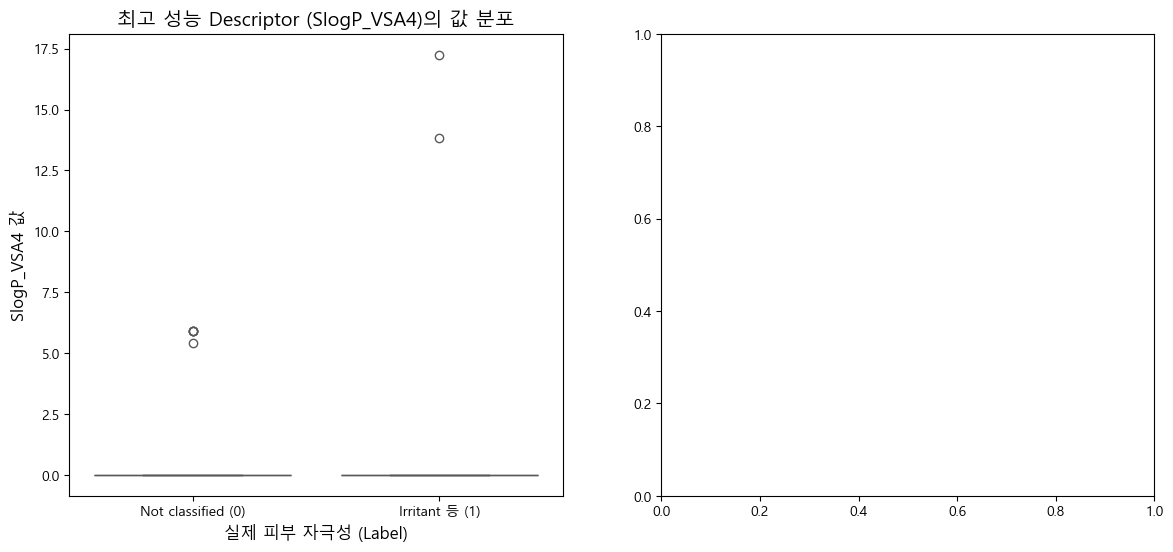

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 한글 폰트 설정 (보고서용으로 깔끔하게 보이도록 설정)
# 윈도우 사용자는 'Malgun Gothic', 맥 사용자는 'AppleGothic'을 사용하세요.
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 그래프 그릴 도화지 준비 (1행 2열로 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =======================================================
# 1. 최고 성능 Descriptor의 데이터 분포 (박스 플롯)
# =======================================================
# 시각화를 위해 df_final의 라벨과 df_desc의 Descriptor 값을 합친 데이터프레임 임시 생성
plot_data = pd.DataFrame({
    'Label': df_final['label'].map({0: 'Not classified (0)', 1: 'Irritant 등 (1)'}),
    'Descriptor_Value': df_desc[best_descriptor]
})

# 박스 플롯 그리기
sns.boxplot(data=plot_data, x='Label', y='Descriptor_Value', ax=axes[0], palette='Set2')
axes[0].set_title(f'최고 성능 Descriptor ({best_descriptor})의 값 분포', fontsize=14)
axes[0].set_xlabel('실제 피부 자극성 (Label)', fontsize=12)
axes[0].set_ylabel(f'{best_descriptor} 값', fontsize=12)

# =======================================================
# 2. 로지스틱 회귀 모델의 분류 성능 (혼동 행렬 히트맵)
# =======================================================
# 앞서 3단계에서 학습된 model을 이용해 전체 데이터 예측값 뽑기
X_best = df_desc[[best_descriptor]]
y_true = df_final['label']
y_pred = model.predict(X_best)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred)

# 히트맵 그리기
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            annot_kws={'size': 15}, cbar=False,
            xticklabels=['예측: 0 (안전)', '예측: 1 (자극)'], 
            yticklabels=['실제: 0 (안전)', '실제: 1 (자극)'])

axes[1].set_title(f'모델 분류 결과 (정확도: {best_score*100:.1f}%)', fontsize=14)
axes[1].set_xlabel('모델이 예측한 값', fontsize=12)
axes[1].set_ylabel('실제 정답', fontsize=12)

# 그래프 간격 깔끔하게 조정 후 출력
plt.tight_layout()
plt.show()

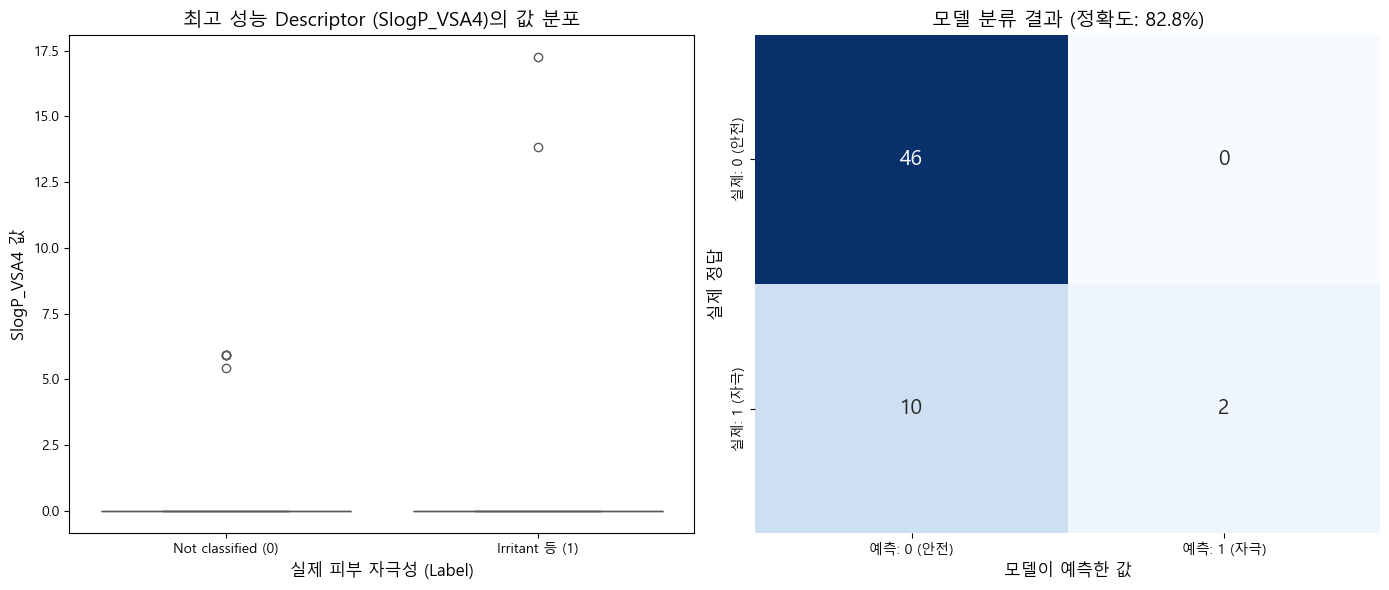

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

# 한글 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

# 그래프 그릴 도화지 준비
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =======================================================
# 1. 최고 성능 Descriptor의 데이터 분포 (박스 플롯)
# =======================================================
plot_data = pd.DataFrame({
    'Label': df_final['label'].map({0: 'Not classified (0)', 1: 'Irritant 등 (1)'}),
    'Descriptor_Value': df_desc[best_descriptor]
})

sns.boxplot(data=plot_data, x='Label', y='Descriptor_Value', ax=axes[0], palette='Set2')
axes[0].set_title(f'최고 성능 Descriptor ({best_descriptor})의 값 분포', fontsize=14)
axes[0].set_xlabel('실제 피부 자극성 (Label)', fontsize=12)
axes[0].set_ylabel(f'{best_descriptor} 값', fontsize=12)

# =======================================================
# 2. 로지스틱 회귀 모델의 분류 성능 (혼동 행렬 히트맵)
# =======================================================
X_best = df_desc[[best_descriptor]]
y_true = df_final['label']

# ★ 에러 해결 포인트: 1등 Descriptor로 모델을 다시 학습시킵니다 ★
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_best, y_true)

# 다시 학습된 모델로 예측 수행
y_pred = final_model.predict(X_best)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred)

# 히트맵 그리기
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            annot_kws={'size': 15}, cbar=False,
            xticklabels=['예측: 0 (안전)', '예측: 1 (자극)'], 
            yticklabels=['실제: 0 (안전)', '실제: 1 (자극)'])

axes[1].set_title(f'모델 분류 결과 (정확도: {best_score*100:.1f}%)', fontsize=14)
axes[1].set_xlabel('모델이 예측한 값', fontsize=12)
axes[1].set_ylabel('실제 정답', fontsize=12)

plt.tight_layout()
plt.show()

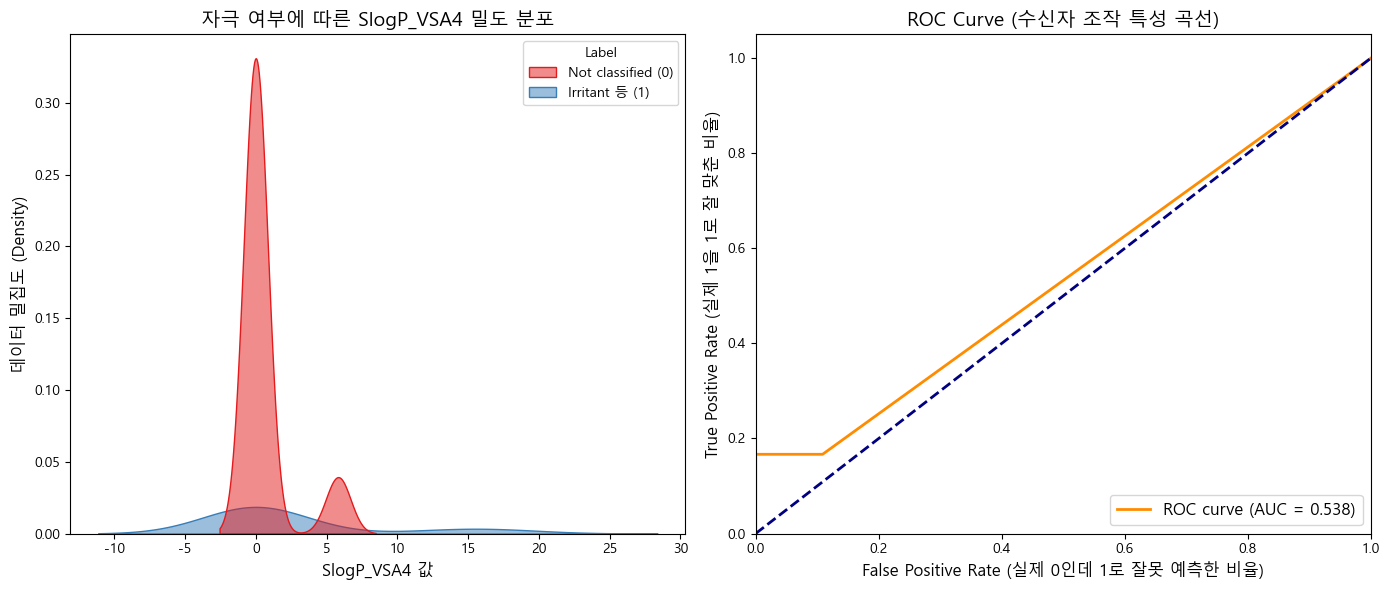

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 한글 폰트 및 마이너스 깨짐 방지 설정
plt.rc('font', family='Malgun Gothic') # 맥 유저는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =======================================================
# 1. 두 그룹의 데이터 밀도 그래프 (KDE Plot)
# =======================================================
plot_data = pd.DataFrame({
    'Label': df_final['label'].map({0: 'Not classified (0)', 1: 'Irritant 등 (1)'}),
    'Descriptor_Value': df_desc[best_descriptor]
})

# fill=True로 산포도 아래를 색칠해서 더 예쁘게 만듦
sns.kdeplot(data=plot_data, x='Descriptor_Value', hue='Label', fill=True, 
            alpha=0.5, palette='Set1', ax=axes[0])
axes[0].set_title(f'자극 여부에 따른 {best_descriptor} 밀도 분포', fontsize=14)
axes[0].set_xlabel(f'{best_descriptor} 값', fontsize=12)
axes[0].set_ylabel('데이터 밀집도 (Density)', fontsize=12)

# =======================================================
# 2. ROC 곡선 (ROC Curve)
# =======================================================
# 모델이 '1(자극성)'이라고 예측할 확률값 추출
y_pred_proba = final_model.predict_proba(X_best)[:, 1]

# FPR(False Positive Rate), TPR(True Positive Rate) 계산
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# ROC 곡선 그리기
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 50% 확률의 기준선
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (실제 0인데 1로 잘못 예측한 비율)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (실제 1을 1로 잘 맞춘 비율)', fontsize=12)
axes[1].set_title('ROC Curve (수신자 조작 특성 곡선)', fontsize=14)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings

warnings.filterwarnings('ignore') # 경고 메시지 숨김

# =======================================================
# 1. 다양한 핑거프린트 추출 함수 정의
# =======================================================
def get_morgan_fp(smiles, radius=2, nBits=1024):
    """Morgan Fingerprint (반경 2, 1024비트) 추출"""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        return np.array(fp)
    return np.zeros((nBits,))

def get_maccs_fp(smiles):
    """MACCS Keys (167비트) 추출"""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = MACCSkeys.GenMACCSKeys(mol)
        return np.array(fp)
    return np.zeros((167,))

print("핑거프린트 변환 중입니다. 잠시만 기다려주세요...")
X_morgan = np.vstack(df_final['processed_SMILES'].apply(get_morgan_fp))
X_maccs = np.vstack(df_final['processed_SMILES'].apply(get_maccs_fp))
y = df_final['label']

# =======================================================
# 2. 실험 조건 세팅 (데이터셋 리스트 & 모델 리스트)
# =======================================================
# 실험할 데이터들
datasets = {
    'Morgan Fingerprint (1024 bits)': X_morgan,
    'MACCS Keys (167 bits)': X_maccs
}

# 실험할 모델들
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (Support Vector Machine)': SVC(random_state=42)
}

# =======================================================
# 3. 반복문을 통한 다중 실험 진행 (Grid Search 개념)
# =======================================================
experiment_results = []
print("모델 학습 및 성능 평가를 시작합니다...")

# 데이터 종류별로 반복
for data_name, X_data in datasets.items():
    # 모델 종류별로 반복
    for model_name, model in models.items():
        
        # 교수님 지시대로 전체 데이터로 학습(fit)
        model.fit(X_data, y)
        
        # 전체 데이터에 대한 정확도(score) 계산
        score = model.score(X_data, y)
        
        # 결과를 딕셔너리 형태로 리스트에 저장
        experiment_results.append({
            'Feature Type': data_name,
            'Model Algorithm': model_name,
            'Accuracy': score
        })

# =======================================================
# 4. 결과 집계 및 순위표 출력
# =======================================================
# 리스트를 데이터프레임으로 변환
df_results = pd.DataFrame(experiment_results)

# 정확도(Accuracy)가 높은 순서대로 내림차순 정렬
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n🏆 [실험 결과 종합 순위표] 🏆")
display(df_results)

핑거프린트 변환 중입니다. 잠시만 기다려주세요...
모델 학습 및 성능 평가를 시작합니다...


[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerator
[12:46:09] DEPRECATION WARNING: please use MorganGenerat


🏆 [실험 결과 종합 순위표] 🏆


,Feature Type,Model Algorithm,Accuracy
0,Morgan Fingerprint (1024 bits),Random Forest,0.948276
1,MACCS Keys (167 bits),Random Forest,0.948276
2,Morgan Fingerprint (1024 bits),Logistic Regression,0.931034
3,MACCS Keys (167 bits),Logistic Regression,0.879310
4,Morgan Fingerprint (1024 bits),SVM (Support Vector Machine),0.844828
5,MACCS Keys (167 bits),SVM (Support Vector Machine),0.827586


In [18]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# =======================================================
# 3. 반복문을 통한 다중 실험 진행 (Metrics 추가)
# =======================================================
experiment_results = []
print("모델 학습 및 세부 성능 평가를 시작합니다...")

# 데이터 종류별로 반복 (X_morgan, X_maccs)
for data_name, X_data in datasets.items():
    # 모델 종류별로 반복 (Logistic, RF, SVM)
    for model_name, model in models.items():
        
        # 모델 학습
        model.fit(X_data, y)
        
        # 예측값 뽑기 (혼동행렬을 구하려면 정답과 예측값이 필요함)
        y_pred = model.predict(X_data)
        
        # 혼동 행렬(Confusion Matrix) 계산
        cm = confusion_matrix(y, y_pred)
        # cm.ravel()은 2x2 행렬을 tn, fp, fn, tp 4개의 값으로 순서대로 분해해 줍니다.
        tn, fp, fn, tp = cm.ravel() 
        
        # 평가지표 계산
        accuracy = (tp + tn) / (tp + tn + fp + fn) # 정확도
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 # 민감도
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 # 특이도
        
        # 결과를 딕셔너리 형태로 리스트에 저장
        experiment_results.append({
            'Feature Type': data_name,
            'Model Algorithm': model_name,
            'Accuracy': round(accuracy, 4),
            'Sensitivity (민감도)': round(sensitivity, 4),
            'Specificity (특이도)': round(specificity, 4),
            'Confusion Matrix (TP, TN, FP, FN)': f"TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}"
        })

# =======================================================
# 4. 결과 집계 및 순위표 출력
# =======================================================
# 리스트를 데이터프레임으로 변환
df_results = pd.DataFrame(experiment_results)

# 정확도(Accuracy)가 높은 순서대로 내림차순 정렬
df_results = df_results.sort_values(by=['Accuracy', 'Sensitivity (민감도)'], ascending=[False, False]).reset_index(drop=True)

print("\n🏆 [업그레이드된 실험 결과 종합 순위표] 🏆")
display(df_results)

모델 학습 및 세부 성능 평가를 시작합니다...

🏆 [업그레이드된 실험 결과 종합 순위표] 🏆


,Feature Type,Model Algorithm,Accuracy,Sensitivity (민감도),Specificity (특이도),"Confusion Matrix (TP, TN, FP, FN)"
0,Morgan Fingerprint (1024 bits),Random Forest,0.9483,1.0000,0.9348,"TP:12, TN:43, FP:3, FN:0"
1,MACCS Keys (167 bits),Random Forest,0.9483,1.0000,0.9348,"TP:12, TN:43, FP:3, FN:0"
2,Morgan Fingerprint (1024 bits),Logistic Regression,0.9310,0.9167,0.9348,"TP:11, TN:43, FP:3, FN:1"
3,MACCS Keys (167 bits),Logistic Regression,0.8793,0.4167,1.0000,"TP:5, TN:46, FP:0, FN:7"
4,Morgan Fingerprint (1024 bits),SVM (Support Vector Machine),0.8448,0.2500,1.0000,"TP:3, TN:46, FP:0, FN:9"
5,MACCS Keys (167 bits),SVM (Support Vector Machine),0.8276,0.1667,1.0000,"TP:2, TN:46, FP:0, FN:10"
